# Patrón 7 Plan-and-Execute

### ¿Qué es?
El patrón **Plan-and-Execute** separa el **razonamiento de alto nivel** (planificación) de la **ejecución** de tareas. Un LLM Planner genera un plan estructurado de subtareas, un Executor Agent las ejecuta secuencialmente, y un Re-Planner evalúa si es necesario ajustar el plan.

Caso de uso: Análisis de Supply Chain

Dataset: DataCo Smart Supply Chain (Kaggle) + API pública USAID
Caso real: Agente que recibe una pregunta de negocio compleja, genera un plan multi-paso, ejecuta análisis de datos sobre el CSV, y entrega recomendaciones accionables.

Dependencias:
```bash
!pip install -q langgraph langchain langchain-anthropic langchain-community \
    pandas numpy matplotlib seaborn openpyxl requests
```


Diagrama:

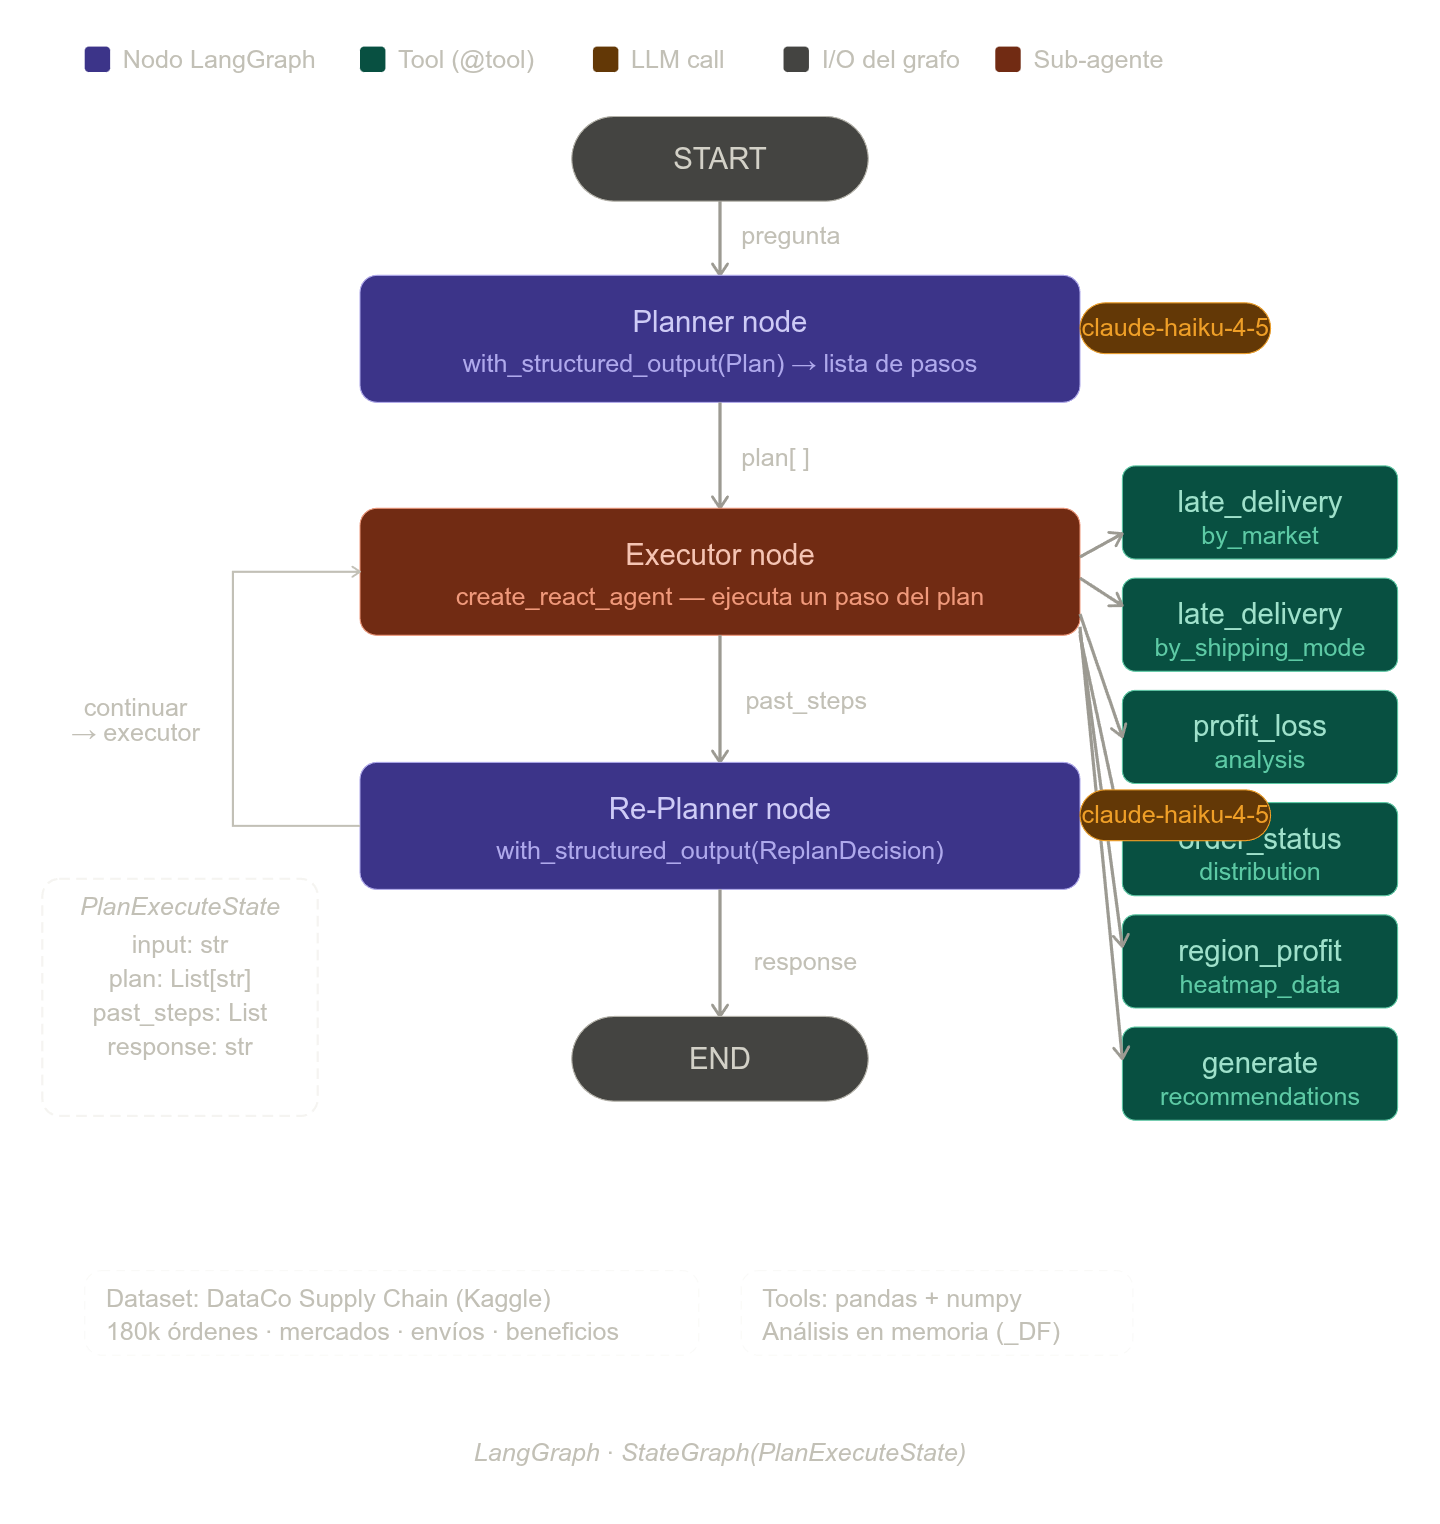

Nodos/Componentes:

|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|START|I/O del grafo|Punto de entrada|Recibe la pregunta de negocio del usuario e inicializa el PlanExecuteState con input, plan=[], past_steps=[], response=None.|
|planner_node|Nodo LangGraph|Genera el plan|Invoca el LLM con with_structured_output(Plan) para producir una lista ordenada de 3–6 pasos de análisis a ejecutar. El plan queda en state["plan"].|
|executor_node|Nodo LangGraph|Ejecuta un paso|Toma state["plan"][0], lo pasa al executor_agent (ReAct) con el contexto acumulado de pasos anteriores, y registra el resultado en state["past_steps"]. Elimina el paso completado del plan.|
|replanner_node|Nodo LangGraph|Evalúa y decide|Recibe pasos completados + pendientes, invoca el LLM con with_structured_output(ReplanDecision). Si hay suficiente información, llena response (finalizar); si no, ajusta remaining_steps (continuar).|
|should_end|Edge condicional|Ruta el flujo|Función que devuelve END si state["response"] está lleno, o "executor" si quedan pasos pendientes. Implementa el loop adaptativo del patrón.|
|PlanExecuteState|TypedDict (State)|Estado compartido|Objeto que fluye entre todos los nodos: input (pregunta), plan (pasos pendientes), past_steps (historial con reducer operator.add), response (respuesta final).|
|Plan|Pydantic BaseModel|Schema de salida|Estructura que el Planner LLM debe producir: steps: List[str]. Garantiza output parseado y evita texto libre no estructurado.|
|ReplanDecision|Pydantic BaseModel|Schema de salida|Estructura que el Re-Planner LLM debe producir: response: Optional[str] y remaining_steps: Optional[List[str]].|
|executor_agent|Sub-agente ReAct|Ejecuta tools|create_react_agent(llm, tools) — agente interno que decide qué herramienta llamar para resolver cada paso del plan. Loop Reason+Act hasta completar la subtarea.|
|late_delivery_by_market|Tool @tool|Análisis pandas|Agrupa el DataFrame por market, calcula late_rate_pct y avg_delay_days. Identifica los mercados con mayor porcentaje de entregas tardías.|
|late_delivery_by_shipping_mode|Tool @tool|Análisis pandas|Agrupa por modo de envío (shipping_mode), calcula tasa de retrasos. Compara Standard Class vs Same Day vs First Class.|
|profit_loss_analysis|Tool @tool|Análisis pandas|Filtra órdenes con benefit_per_order < 0, agrupa por categoría de producto, calcula pérdida total y promedio. Identifica SKUs problemáticos.|
|order_status_distribution|Tool @tool|Análisis pandas|Cuenta y agrupa por order_status (COMPLETE, CANCELED, SUSPECTED_FRAUD, etc.), calcula porcentaje y ventas asociadas por estado.|
|region_profit_heatmap_data|Tool @tool|Análisis pandas|Genera tabla pivote region × department con beneficio promedio. Detecta combinaciones región-departamento con menor rentabilidad.|
|generate_recommendations|Tool @tool + LLM|Síntesis final|Recibe el contexto acumulado de todos los pasos previos y llama al LLM directamente para generar 5 recomendaciones accionables priorizadas por impacto.|
|_DF|Variable global|Fuente de datos|DataFrame pandas cargado desde el dataset DataCo Supply Chain (Kaggle, 180k filas). Accesible por todas las tools como estado de datos inmutable.|
|claude-haiku-4-5|LLM call|Inferencia|Modelo usado en Planner y Re-Planner vía ChatAnthropic. Elegido por velocidad y costo en nodos de planificación estructurada.|
|END|I/O del grafo|Punto de salida|El grafo termina aquí cuando replanner_node produce un response no nulo. El estado final contiene el reporte ejecutivo completo y el historial de past_steps.|



### Cuándo usarlo
- ✅ Tareas de investigación multi-paso
- ✅ Automatización de procesos de negocio complejos
- ✅ Agentes de software engineering (planificar → codificar → testear)
- ❌ Tasks simples que no requieren planificación explícita


In [19]:
!pip install -q langgraph langchain langchain-anthropic langchain-community \
    pandas numpy matplotlib seaborn openpyxl requests

In [2]:
import os
import json
import pandas as pd
import numpy as np
import requests
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from typing import TypedDict, List, Optional, Annotated
import operator

from pydantic import BaseModel, Field
from langchain_anthropic import ChatAnthropic
from langchain.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent

In [4]:
llm = ChatAnthropic(model="claude-sonnet-4-6", temperature=0)
print("✅ LLM listo:", llm.model)

✅ LLM listo: claude-sonnet-4-6


### Descarga del dataset (Kaggle API o directo)

In [5]:
# Celda 3: Descarga del dataset
# ─────────────────────────────────────────────────────────────
# OPCIÓN A: Kaggle API (necesita ~/.kaggle/kaggle.json)
# !pip install -q kaggle
# !kaggle datasets download -d shashwatwork/dataco-smart-supply-chain-for-big-data-analysis
# !unzip -o dataco-smart-supply-chain-for-big-data-analysis.zip
#
# OPCIÓN B: Descarga directa desde mirror público en GitHub
# ─────────────────────────────────────────────────────────────

CSV_URL = (
    "https://raw.githubusercontent.com/"
    "dsrscientist/dataset1/master/DataCoSupplyChainDataset.csv"
)

print("⬇️ Descargando DataCo Supply Chain Dataset...")
try:
    df_raw = pd.read_csv(CSV_URL, encoding="ISO-8859-1")
    print(f"✅ Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
except Exception as e:
    print(f"⚠️  Mirror falló ({e}). Usando datos sintéticos representativos...")
    # ── Datos sintéticos con la misma estructura del DataCo ──────────────────
    np.random.seed(42)
    n = 5000
    categories   = ["Fishing", "Cleats", "Camping & Hiking", "Cardio Equipment", "Water Sports"]
    departments  = ["Fan Shop", "Apparel", "Golf", "Footwear", "Technology"]
    markets      = ["LATAM", "Europe", "Pacific Asia", "USCA", "Africa"]
    ship_modes   = ["Standard Class", "Second Class", "First Class", "Same Day"]
    order_status = ["COMPLETE", "PENDING", "CLOSED", "CANCELED", "SUSPECTED_FRAUD"]

    df_raw = pd.DataFrame({
        "Order Id":            range(1, n + 1),
        "order date (DateOrders)": pd.date_range("2015-01-01", periods=n, freq="2h"),
        "Category Name":       np.random.choice(categories, n),
        "Department Name":     np.random.choice(departments, n),
        "Market":              np.random.choice(markets, n, p=[0.35, 0.25, 0.20, 0.15, 0.05]),
        "Order Country":       np.random.choice(["Mexico","France","Germany","USA","Brazil","India"], n),
        "Order Region":        np.random.choice(["Central America","Western Europe","South America","North America"], n),
        "Order Status":        np.random.choice(order_status, n, p=[0.55, 0.15, 0.15, 0.10, 0.05]),
        "Shipping Mode":       np.random.choice(ship_modes, n, p=[0.60, 0.20, 0.15, 0.05]),
        "Days for shipping (real)":     np.random.randint(1, 10, n),
        "Days for shipment (scheduled)":np.random.randint(1, 6, n),
        "Sales":               np.random.uniform(10, 1500, n).round(2),
        "Order Item Quantity": np.random.randint(1, 10, n),
        "Order Item Profit Ratio": np.random.uniform(-0.1, 0.5, n).round(4),
        "Order Item Total":    np.random.uniform(10, 5000, n).round(2),
        "Benefit per order":   np.random.uniform(-200, 800, n).round(2),
        "Latitude":            np.random.uniform(-35, 65, n).round(4),
        "Longitude":           np.random.uniform(-120, 140, n).round(4),
    })
    print(f"✅ Dataset sintético generado: {df_raw.shape}")

df_raw.head(3)

⬇️ Descargando DataCo Supply Chain Dataset...
⚠️  Mirror falló (HTTP Error 404: Not Found). Usando datos sintéticos representativos...
✅ Dataset sintético generado: (5000, 18)


,Order Id,order date (DateOrders),Category Name,Department Name,Market,Order Country,Order Region,Order Status,Shipping Mode,Days for shipping (real),Days for shipment (scheduled),Sales,Order Item Quantity,Order Item Profit Ratio,Order Item Total,Benefit per order,Latitude,Longitude
0,1,2015-01-01 00:00:00,Cardio Equipment,Apparel,LATAM,Mexico,North America,COMPLETE,Second Class,7,2,1011.42,7,0.4001,1350.48,450.76,10.2154,17.0009
1,2,2015-01-01 02:00:00,Water Sports,Technology,USCA,Brazil,Western Europe,PENDING,Standard Class,4,4,1060.15,3,-0.0335,2160.03,600.43,59.3360,92.9359
2,3,2015-01-01 04:00:00,Camping & Hiking,Footwear,LATAM,Brazil,Central America,COMPLETE,Standard Class,7,3,1257.30,4,0.3571,644.99,188.63,0.2845,-64.0232


### Exploración rápida del dataset

In [6]:
# Celda 4: Exploración rápida
print("=" * 60)
print("COLUMNAS DISPONIBLES")
print("=" * 60)
for col in df_raw.columns:
    print(f"  • {col}: {df_raw[col].dtype}  | nulos: {df_raw[col].isna().sum()}")

print("\n" + "=" * 60)
print("ESTADÍSTICAS CLAVE")
print("=" * 60)
numeric_cols = ["Days for shipping (real)", "Days for shipment (scheduled)",
                "Sales", "Benefit per order", "Order Item Profit Ratio"]
existing = [c for c in numeric_cols if c in df_raw.columns]
print(df_raw[existing].describe().round(2))

COLUMNAS DISPONIBLES
  • Order Id: int64  | nulos: 0
  • order date (DateOrders): datetime64[ns]  | nulos: 0
  • Category Name: object  | nulos: 0
  • Department Name: object  | nulos: 0
  • Market: object  | nulos: 0
  • Order Country: object  | nulos: 0
  • Order Region: object  | nulos: 0
  • Order Status: object  | nulos: 0
  • Shipping Mode: object  | nulos: 0
  • Days for shipping (real): int64  | nulos: 0
  • Days for shipment (scheduled): int64  | nulos: 0
  • Sales: float64  | nulos: 0
  • Order Item Quantity: int64  | nulos: 0
  • Order Item Profit Ratio: float64  | nulos: 0
  • Order Item Total: float64  | nulos: 0
  • Benefit per order: float64  | nulos: 0
  • Latitude: float64  | nulos: 0
  • Longitude: float64  | nulos: 0

ESTADÍSTICAS CLAVE
       Days for shipping (real)  Days for shipment (scheduled)    Sales  \
count                   5000.00                        5000.00  5000.00   
mean                       5.06                           3.01   757.24   
std      

### Preprocesamiento

In [8]:
# Celda 5: Preprocesamiento limpio del dataset
df = df_raw.copy()

# Normalizar nombres de columnas
df.columns = (df.columns
              .str.strip()
              .str.replace(r"[\s\(\)\/]", "_", regex=True)
              .str.lower()
              .str.replace(r"_+", "_", regex=True)
              .str.strip("_"))

# Columna de retraso en días
if "days_for_shipping_real" in df.columns and "days_for_shipment_scheduled" in df.columns:
    df["delay_days"] = df["days_for_shipping_real"] - df["days_for_shipment_scheduled"]
    df["is_late"]    = (df["delay_days"] > 0).astype(int)

# Columna de pérdida
if "benefit_per_order" in df.columns:
    df["is_loss"] = (df["benefit_per_order"] < 0).astype(int)

print("✅ Columnas tras preprocesar:")
print(list(df.columns))
print(f"\nRetrasos detectados: {df['is_late'].sum():,} de {len(df):,} órdenes "
      f"({df['is_late'].mean()*100:.1f}%)")

✅ Columnas tras preprocesar:
['order_id', 'order_date_dateorders', 'category_name', 'department_name', 'market', 'order_country', 'order_region', 'order_status', 'shipping_mode', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'sales', 'order_item_quantity', 'order_item_profit_ratio', 'order_item_total', 'benefit_per_order', 'latitude', 'longitude', 'delay_days', 'is_late', 'is_loss']

Retrasos detectados: 3,394 de 5,000 órdenes (67.9%)


### Definición de herramientas para el agente

In [9]:
# Celda 6: Tools para el Executor Agent
# El agente usará estas funciones para explorar el dataset

# Variable global — el df procesado está disponible para las tools
_DF = df.copy()

@tool
def late_delivery_by_market(top_n: int = 5) -> str:
    """
    Calcula la tasa de retrasos (late delivery rate) agrupada por mercado (market).
    Retorna los top_n mercados con mayor % de retrasos y el retraso promedio en días.
    """
    if "market" not in _DF.columns:
        return "Columna 'market' no encontrada en el dataset."

    grouped = _DF.groupby("market").agg(
        total_orders   = ("is_late", "count"),
        late_orders    = ("is_late", "sum"),
        avg_delay_days = ("delay_days", "mean"),
        total_sales    = ("sales", "sum") if "sales" in _DF.columns else ("is_late", "count")
    ).reset_index()

    grouped["late_rate_pct"] = (grouped["late_orders"] / grouped["total_orders"] * 100).round(1)
    grouped["avg_delay_days"] = grouped["avg_delay_days"].round(2)
    result = grouped.sort_values("late_rate_pct", ascending=False).head(top_n)
    return result.to_markdown(index=False)


@tool
def late_delivery_by_shipping_mode() -> str:
    """
    Analiza cómo el modo de envío (shipping_mode) afecta la tasa de retrasos.
    Retorna tabla con late_rate_pct y avg_delay_days por modo de envío.
    """
    if "shipping_mode" not in _DF.columns:
        col = next((c for c in _DF.columns if "ship" in c and "mode" in c), None)
        if not col:
            return "No se encontró columna de modo de envío."
    else:
        col = "shipping_mode"

    grouped = _DF.groupby(col).agg(
        total_orders   = ("is_late", "count"),
        late_orders    = ("is_late", "sum"),
        avg_delay_days = ("delay_days", "mean"),
    ).reset_index()
    grouped["late_rate_pct"] = (grouped["late_orders"] / grouped["total_orders"] * 100).round(1)
    return grouped.sort_values("late_rate_pct", ascending=False).to_markdown(index=False)


@tool
def profit_loss_analysis(top_n: int = 5) -> str:
    """
    Identifica las categorías de productos (category_name) con mayor pérdida económica.
    Retorna top_n categorías por total de pérdidas, con pérdida promedio por orden.
    """
    cat_col = next((c for c in _DF.columns if "category" in c and "name" in c), None)
    if not cat_col:
        cat_col = next((c for c in _DF.columns if "category" in c), None)
    if not cat_col or "benefit_per_order" not in _DF.columns:
        return "Columnas requeridas no encontradas: category_name, benefit_per_order."

    losses = _DF[_DF["benefit_per_order"] < 0].groupby(cat_col).agg(
        loss_orders     = ("is_loss", "count"),
        total_loss      = ("benefit_per_order", "sum"),
        avg_loss        = ("benefit_per_order", "mean"),
    ).reset_index()
    losses["total_loss"] = losses["total_loss"].round(2)
    losses["avg_loss"]   = losses["avg_loss"].round(2)
    result = losses.sort_values("total_loss").head(top_n)
    return result.to_markdown(index=False)


@tool
def order_status_distribution() -> str:
    """
    Muestra la distribución de estados de órdenes (order_status) y el impacto
    en ventas totales. Útil para identificar fraude o cancelaciones excesivas.
    """
    status_col = next((c for c in _DF.columns if "status" in c), None)
    if not status_col:
        return "No se encontró columna de status."

    grouped = _DF.groupby(status_col).agg(
        count       = (status_col, "count"),
        total_sales = ("sales", "sum") if "sales" in _DF.columns else (status_col, "count"),
    ).reset_index()
    grouped["pct"] = (grouped["count"] / grouped["count"].sum() * 100).round(1)
    return grouped.sort_values("count", ascending=False).to_markdown(index=False)


@tool
def region_profit_heatmap_data() -> str:
    """
    Calcula beneficio promedio por orden agrupado por región (order_region) y
    departamento (department_name). Útil para identificar combinaciones problemáticas.
    """
    region_col = next((c for c in _DF.columns if "region" in c), None)
    dept_col   = next((c for c in _DF.columns if "department" in c), None)

    if not region_col or not dept_col or "benefit_per_order" not in _DF.columns:
        return "Columnas requeridas no encontradas."

    pivot = _DF.groupby([region_col, dept_col])["benefit_per_order"].mean().round(2)
    return pivot.reset_index().to_markdown(index=False)


@tool
def generate_recommendations(context: str) -> str:
    """
    Dado un contexto con hallazgos de análisis, genera recomendaciones
    accionables de negocio. Pasar el resumen de los análisis previos como 'context'.
    """
    response = llm.invoke(
        f"""Eres un consultor experto en supply chain y logística.
Basándote en los siguientes hallazgos de análisis de datos de la empresa DataCo:

{context}

Genera exactamente 5 recomendaciones accionables, priorizadas por impacto.
Cada recomendación debe tener:
- Título corto
- Acción concreta a implementar
- KPI para medir el éxito
- Plazo estimado (corto/mediano/largo)

Formato: lista numerada clara y concisa."""
    )
    return response.content


tools = [
    late_delivery_by_market,
    late_delivery_by_shipping_mode,
    profit_loss_analysis,
    order_status_distribution,
    region_profit_heatmap_data,
    generate_recommendations,
]

print(f"✅ {len(tools)} herramientas registradas:")
for t in tools:
    print(f"   • {t.name}: {t.description[:60]}...")

✅ 6 herramientas registradas:
   • late_delivery_by_market: Calcula la tasa de retrasos (late delivery rate) agrupada po...
   • late_delivery_by_shipping_mode: Analiza cómo el modo de envío (shipping_mode) afecta la tasa...
   • profit_loss_analysis: Identifica las categorías de productos (category_name) con m...
   • order_status_distribution: Muestra la distribución de estados de órdenes (order_status)...
   • region_profit_heatmap_data: Calcula beneficio promedio por orden agrupado por región (or...
   • generate_recommendations: Dado un contexto con hallazgos de análisis, genera recomenda...


### Estado y modelos Pydantic del grafo

In [10]:
# Celda 7: Definición del State y schemas Pydantic para outputs estructurados

class Plan(BaseModel):
    """Plan de ejecución generado por el Planner LLM."""
    steps: List[str] = Field(
        description="Lista ordenada de pasos a ejecutar para responder la pregunta de negocio."
    )

class ReplanDecision(BaseModel):
    """Decisión del Re-Planner tras ver los pasos completados."""
    response: Optional[str] = Field(
        default=None,
        description="Respuesta final SOLO si ya tienes suficiente información para responder. "
                    "Si necesitas más pasos, deja este campo en None."
    )
    remaining_steps: Optional[List[str]] = Field(
        default=None,
        description="Pasos restantes si el plan necesita continuar o ajustarse. "
                    "None si ya se puede responder."
    )

class PlanExecuteState(TypedDict):
    """Estado compartido del grafo Plan-and-Execute."""
    input:      str                                # Pregunta de negocio original
    plan:       List[str]                          # Plan de pasos pendientes
    past_steps: Annotated[List[tuple], operator.add]  # Pasos completados + resultados
    response:   Optional[str]                     # Respuesta final del agente

print("✅ Schemas definidos: Plan, ReplanDecision, PlanExecuteState")

✅ Schemas definidos: Plan, ReplanDecision, PlanExecuteState


### Nodos del grafo: Planner, Executor, Re-Planner

In [11]:
# Celda 8: Implementación de los 3 nodos del patrón Plan-and-Execute

# ── NODO 1: PLANNER ──────────────────────────────────────────────────────────
planner_llm = llm.with_structured_output(Plan)

PLANNER_SYSTEM = """Eres un analista de supply chain experto en LangGraph.
Tu rol es crear planes de análisis de datos PASO A PASO para responder preguntas de negocio.

Tienes acceso a estas herramientas de análisis:
- late_delivery_by_market: tasa de retrasos por mercado
- late_delivery_by_shipping_mode: impacto del modo de envío en retrasos
- profit_loss_analysis: categorías de productos con pérdidas
- order_status_distribution: distribución de estados de órdenes
- region_profit_heatmap_data: beneficio por región y departamento
- generate_recommendations: genera recomendaciones accionables basadas en hallazgos

Crea un plan con 3-6 pasos ordenados lógicamente.
Cada paso debe ser una instrucción clara que usa UNA herramienta específica.
El último paso SIEMPRE debe ser generate_recommendations con el contexto acumulado."""

def planner_node(state: PlanExecuteState):
    """Genera el plan inicial de análisis."""
    print("\n🗺️  PLANNER: Generando plan de análisis...")
    response = planner_llm.invoke(
        [
            {"role": "system", "content": PLANNER_SYSTEM},
            {"role": "user",   "content": f"Pregunta de negocio: {state['input']}"}
        ]
    )
    print(f"   Plan generado con {len(response.steps)} pasos:")
    for i, step in enumerate(response.steps, 1):
        print(f"   {i}. {step}")
    return {"plan": response.steps}


# ── NODO 2: EXECUTOR ─────────────────────────────────────────────────────────
executor_agent = create_react_agent(llm, tools)

def executor_node(state: PlanExecuteState):
    """Ejecuta el primer paso del plan usando el agente ReAct."""
    current_step = state["plan"][0]
    print(f"\n⚙️  EXECUTOR: Ejecutando → '{current_step}'")

    # Contexto acumulado de pasos anteriores
    past_context = ""
    if state.get("past_steps"):
        past_context = "\n\nRESULTADOS ANTERIORES:\n" + "\n\n".join(
            [f"Paso: {s}\nResultado: {r}" for s, r in state["past_steps"]]
        )

    task_prompt = f"{current_step}{past_context}"
    result = executor_agent.invoke({"messages": [("user", task_prompt)]})
    output = result["messages"][-1].content

    print(f"   ✅ Completado ({len(output)} chars)")
    print(f"   Preview: {output[:120]}...")

    return {
        "past_steps": [(current_step, output)],
        "plan": state["plan"][1:],           # Elimina el paso ejecutado del plan
    }


# ── NODO 3: RE-PLANNER ───────────────────────────────────────────────────────
replanner_llm = llm.with_structured_output(ReplanDecision)

REPLANNER_SYSTEM = """Eres el Re-Planner de un sistema Plan-and-Execute para análisis de supply chain.

Tu trabajo es evaluar el progreso:
1. Revisa los pasos completados y sus resultados
2. Revisa los pasos pendientes
3. Decide si ya hay suficiente información para responder la pregunta original
   → Si SÍ: pon la respuesta final en 'response' (resumen ejecutivo completo)
   → Si NO: ajusta 'remaining_steps' si es necesario y déjalo continuar

La respuesta final debe ser un reporte ejecutivo completo con:
- Resumen de hallazgos clave (con datos concretos)
- Recomendaciones accionables
- Próximos pasos"""

def replanner_node(state: PlanExecuteState):
    """Evalúa el progreso y decide continuar, replantear o finalizar."""
    print(f"\n🔄 RE-PLANNER: Pasos completados: {len(state['past_steps'])} | "
          f"Pendientes: {len(state.get('plan', []))}")

    past_summary = "\n\n".join(
        [f"PASO: {s}\nRESULTADO: {r}" for s, r in state["past_steps"]]
    )

    decision = replanner_llm.invoke(
        [
            {"role": "system", "content": REPLANNER_SYSTEM},
            {"role": "user", "content":
                f"PREGUNTA ORIGINAL: {state['input']}\n\n"
                f"PASOS COMPLETADOS:\n{past_summary}\n\n"
                f"PASOS PENDIENTES:\n{chr(10).join(state.get('plan', ['(ninguno)']))}"
            }
        ]
    )

    if decision.response:
        print("   ✅ Re-Planner decide: FINALIZAR con respuesta completa")
        return {"response": decision.response}
    else:
        new_plan = decision.remaining_steps or state.get("plan", [])
        print(f"   ➡️  Re-Planner decide: CONTINUAR con {len(new_plan)} pasos restantes")
        return {"plan": new_plan}


# ── EDGE CONDICIONAL: ¿Seguir o terminar? ────────────────────────────────────
def should_end(state: PlanExecuteState) -> str:
    """Decide si el grafo debe terminar o continuar al executor."""
    if state.get("response"):
        return END
    elif not state.get("plan"):
        # Sin pasos y sin respuesta → forzar finalización
        return END
    return "executor"

print("✅ Nodos definidos: planner_node, executor_node, replanner_node")

✅ Nodos definidos: planner_node, executor_node, replanner_node


### Construcción del grafo

In [12]:
# Celda 9: Construcción y compilación del grafo LangGraph

builder = StateGraph(PlanExecuteState)

# Agregar nodos
builder.add_node("planner",   planner_node)
builder.add_node("executor",  executor_node)
builder.add_node("replanner", replanner_node)

# Definir flujo
builder.add_edge(START,       "planner")    # Siempre empieza en el Planner
builder.add_edge("planner",   "executor")   # Planner → Executor
builder.add_edge("executor",  "replanner")  # Executor → Re-Planner

# Re-Planner decide: ¿terminar (END) o seguir ejecutando?
builder.add_conditional_edges(
    "replanner",
    should_end,
    {END: END, "executor": "executor"}
)

graph = builder.compile()
print("✅ Grafo compilado correctamente")
print("\nEstructura del grafo:")
print(graph.get_graph().draw_ascii())

✅ Grafo compilado correctamente

Estructura del grafo:
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | planner |   
 +---------+   
      *        
      *        
      *        
+----------+   
| executor |   
+----------+   
      *        
      *        
      *        
+-----------+  
| replanner |  
+-----------+  
      .        
      .        
      .        
 +---------+   
 | __end__ |   
 +---------+   


### Visualización del grafo

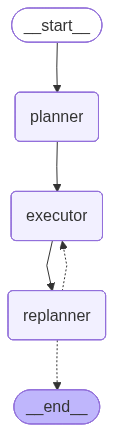

✅ Grafo visualizado


In [13]:
try:
    from IPython.display import Image, display
    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
    print("✅ Grafo visualizado")
except Exception as e:
    print("Diagrama en Mermaid (pega en https://mermaid.live):\n")
    print(graph.get_graph().draw_mermaid())

###  Ejecución del agente con pregunta de negocio

In [14]:
# Celda 11: ¡Ejecutar el agente!

BUSINESS_QUESTION = """
Necesito un análisis completo del rendimiento de la cadena de suministro de DataCo.
Específicamente quiero entender:
1. ¿Cuáles son los mercados y modos de envío con mayor tasa de retrasos?
2. ¿Qué categorías de productos están generando pérdidas?
3. ¿Cuál es la distribución de estados de órdenes y hay signos de fraude?
4. ¿Qué recomendaciones concretas podemos implementar para mejorar el margen y reducir retrasos?

El objetivo es presentar esto al equipo directivo la próxima semana.
"""

print("🚀 INICIANDO AGENTE PLAN-AND-EXECUTE")
print("=" * 70)
print(f"Pregunta de negocio:\n{BUSINESS_QUESTION.strip()}")
print("=" * 70)

initial_state = {
    "input":      BUSINESS_QUESTION,
    "plan":       [],
    "past_steps": [],
    "response":   None,
}

# Ejecutar con streaming para ver el progreso paso a paso
final_state = None
step_count = 0
#graph.invoke()
for event in graph.stream(initial_state, {"recursion_limit": 25}):
    step_count += 1
    node_name = list(event.keys())[0]
    print(f"\n{'─'*50}")
    print(f"Evento {step_count}: [{node_name.upper()}]")

    node_state = event[node_name]
    if "response" in node_state and node_state["response"]:
        final_state = node_state

print(f"\n{'='*70}")
print(f"Ejecución completada en {step_count} eventos")

🚀 INICIANDO AGENTE PLAN-AND-EXECUTE
Pregunta de negocio:
Necesito un análisis completo del rendimiento de la cadena de suministro de DataCo.
Específicamente quiero entender:
1. ¿Cuáles son los mercados y modos de envío con mayor tasa de retrasos?
2. ¿Qué categorías de productos están generando pérdidas?
3. ¿Cuál es la distribución de estados de órdenes y hay signos de fraude?
4. ¿Qué recomendaciones concretas podemos implementar para mejorar el margen y reducir retrasos?

El objetivo es presentar esto al equipo directivo la próxima semana.

🗺️  PLANNER: Generando plan de análisis...
   Plan generado con 6 pasos:
   1. Ejecutar late_delivery_by_market para identificar qué mercados geográficos presentan las mayores tasas de retraso en las entregas.
   2. Ejecutar late_delivery_by_shipping_mode para analizar cómo cada modo de envío (Standard, First Class, Second Class, Same Day) impacta en los retrasos operativos.
   3. Ejecutar profit_loss_analysis para detectar qué categorías y subcateg

### Mostrar respuesta final del agente

In [15]:
# Celda 12: Mostrar el reporte ejecutivo generado por el agente

if final_state and final_state.get("response"):
    print("\n" + "🎯 " * 20)
    print("\n📊 REPORTE EJECUTIVO GENERADO POR EL AGENTE\n")
    print("🎯 " * 20)
    print()
    print(final_state["response"])
else:
    # Si el stream no capturó el estado final, obtenerlo directamente
    result = graph.invoke(initial_state, {"recursion_limit": 25})
    print("\n📊 REPORTE EJECUTIVO:\n")
    print(result.get("response", "⚠️ No se generó respuesta final."))
    final_state = result


🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 

📊 REPORTE EJECUTIVO GENERADO POR EL AGENTE

🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 

# 📊 REPORTE EJECUTIVO — ANÁLISIS DE CADENA DE SUMINISTRO DATACO
### Preparado para presentación al equipo directivo

---

## 🔑 RESUMEN EJECUTIVO

El análisis integral de 5,000 órdenes de DataCo revela **tres crisis simultáneas**: un problema logístico sistémico con tasas de retraso superiores al 63% en todos los mercados, pérdidas estructurales de al menos $96,760 en el segmento deportivo, y un riesgo financiero de hasta $1.14M (30.2% de ventas) por fraude, cancelaciones y órdenes pendientes sin resolver.

---

## 1. 🌎 MERCADOS Y MODOS DE ENVÍO CON MAYOR TASA DE RETRASOS

### Por Mercado Geográfico

| Mercado | Tasa de Retraso | Retraso Promedio | Ventas en Riesgo |
|---------|:-:|:-:|:-:|
| **LATAM** | **69.5%** 🔴 | 2.12 días | $1,339,460 |
| **USCA** | **68.3%** 🔴 | 1.99 días | $573,152 |
| **Pacific Asia** | **68.0%** 🔴 | 2.10 días | $750,696 |
| **Europe*

### Inspección de los pasos ejecutados

In [16]:
# Celda 13: Auditoría — ver todos los pasos que ejecutó el agente

print("🔍 AUDITORÍA DE PASOS EJECUTADOS\n")
print("=" * 70)

if final_state and final_state.get("past_steps"):
    for i, (step, result) in enumerate(final_state["past_steps"], 1):
        print(f"\n{'─'*50}")
        print(f"PASO {i}: {step}")
        print(f"{'─'*50}")
        # Mostrar solo los primeros 400 chars del resultado para no saturar
        preview = result[:400] + ("..." if len(result) > 400 else "")
        print(preview)
else:
    print("No hay pasos registrados en el estado final.")
    print("Tip: ejecuta la celda 11 primero con graph.invoke() en lugar de stream()")

🔍 AUDITORÍA DE PASOS EJECUTADOS

No hay pasos registrados en el estado final.
Tip: ejecuta la celda 11 primero con graph.invoke() en lugar de stream()


### Análisis visual complementario

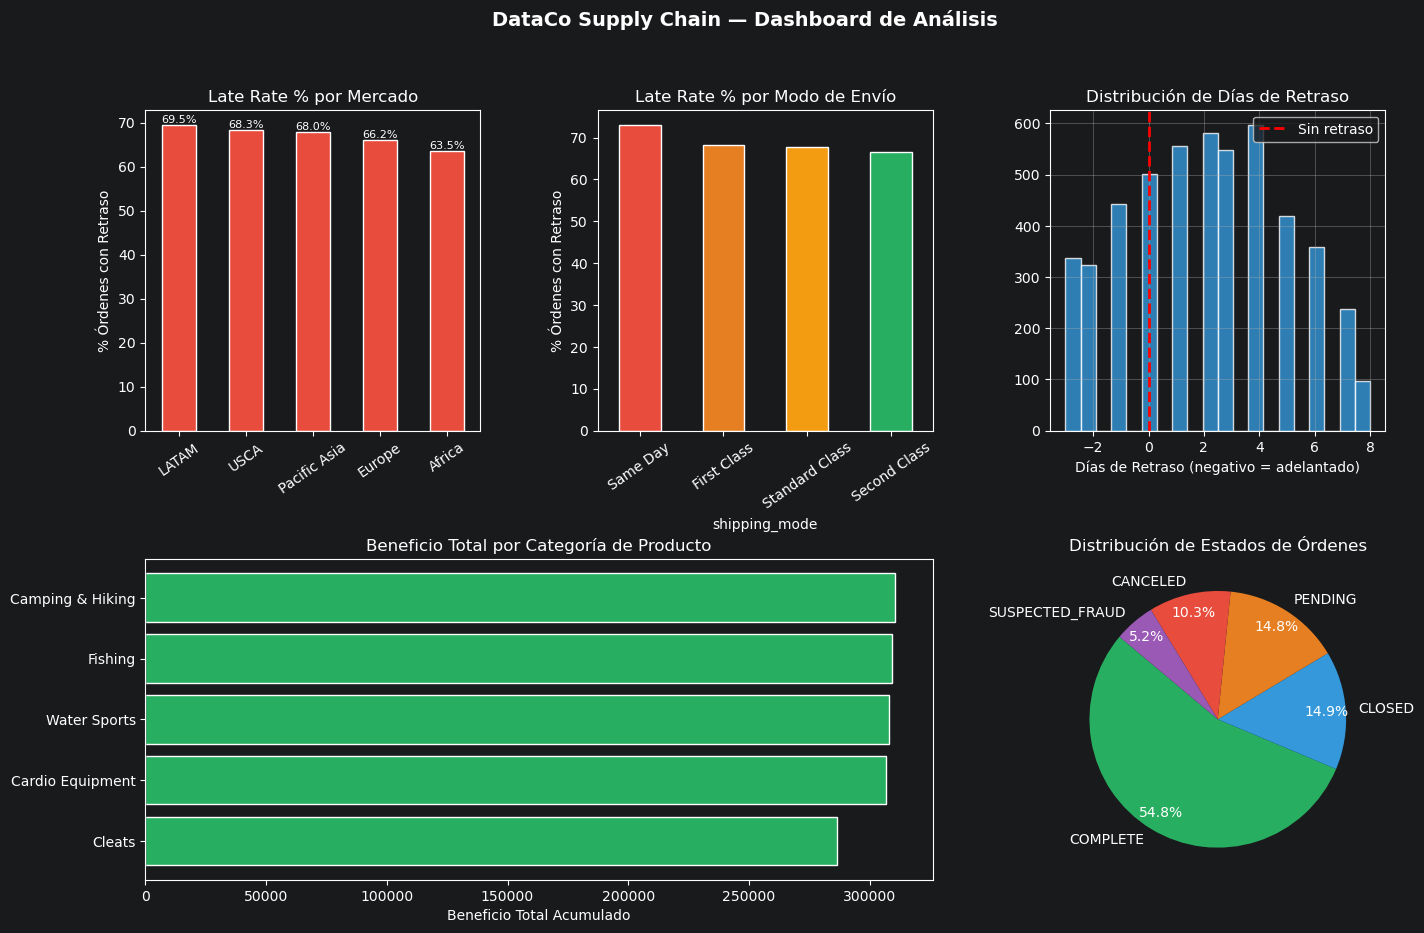

✅ Dashboard guardado como supply_chain_dashboard.png


In [17]:
# Celda 14: Visualizaciones complementarias en pandas/matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
fig.suptitle("DataCo Supply Chain — Dashboard de Análisis", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1) Late rate por mercado
ax1 = fig.add_subplot(gs[0, 0])
if "market" in df.columns and "is_late" in df.columns:
    mkt = df.groupby("market")["is_late"].mean().sort_values(ascending=False) * 100
    mkt.plot(kind="bar", ax=ax1, color="#e74c3c", edgecolor="white")
    ax1.set_title("Late Rate % por Mercado")
    ax1.set_ylabel("% Órdenes con Retraso")
    ax1.set_xlabel("")
    ax1.tick_params(axis="x", rotation=35)
    for bar in ax1.patches:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=8)

# 2) Late rate por Shipping Mode
ax2 = fig.add_subplot(gs[0, 1])
ship_col = next((c for c in df.columns if "ship" in c and "mode" in c), None)
if ship_col and "is_late" in df.columns:
    sm = df.groupby(ship_col)["is_late"].mean().sort_values(ascending=False) * 100
    colors = ["#e74c3c", "#e67e22", "#f39c12", "#27ae60"]
    sm.plot(kind="bar", ax=ax2, color=colors[:len(sm)], edgecolor="white")
    ax2.set_title("Late Rate % por Modo de Envío")
    ax2.set_ylabel("% Órdenes con Retraso")
    ax2.tick_params(axis="x", rotation=35)

# 3) Distribución de delay_days
ax3 = fig.add_subplot(gs[0, 2])
if "delay_days" in df.columns:
    df["delay_days"].clip(-3, 8).hist(bins=20, ax=ax3, color="#3498db",
                                       edgecolor="white", alpha=0.8)
    ax3.axvline(0, color="red", linestyle="--", linewidth=2, label="Sin retraso")
    ax3.set_title("Distribución de Días de Retraso")
    ax3.set_xlabel("Días de Retraso (negativo = adelantado)")
    ax3.legend()

# 4) Profit por categoría
ax4 = fig.add_subplot(gs[1, 0:2])
cat_col = next((c for c in df.columns if "category" in c and "name" in c), None)
if not cat_col:
    cat_col = next((c for c in df.columns if "category" in c), None)
if cat_col and "benefit_per_order" in df.columns:
    cat_profit = df.groupby(cat_col)["benefit_per_order"].agg(["mean", "sum"]).reset_index()
    cat_profit = cat_profit.sort_values("sum")
    colors_p = ["#e74c3c" if x < 0 else "#27ae60" for x in cat_profit["sum"]]
    ax4.barh(cat_profit[cat_col], cat_profit["sum"], color=colors_p, edgecolor="white")
    ax4.axvline(0, color="black", linewidth=1)
    ax4.set_title("Beneficio Total por Categoría de Producto")
    ax4.set_xlabel("Beneficio Total Acumulado")

# 5) Order Status
ax5 = fig.add_subplot(gs[1, 2])
status_col = next((c for c in df.columns if "status" in c), None)
if status_col:
    status_counts = df[status_col].value_counts()
    wedge_colors = ["#27ae60", "#3498db", "#e67e22", "#e74c3c", "#9b59b6"]
    status_counts.plot(kind="pie", ax=ax5, autopct="%1.1f%%",
                       colors=wedge_colors[:len(status_counts)],
                       startangle=140, pctdistance=0.85)
    ax5.set_title("Distribución de Estados de Órdenes")
    ax5.set_ylabel("")

plt.savefig("supply_chain_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard guardado como supply_chain_dashboard.png")

### Segunda ejecución: pregunta diferente (demostrar re-planning)

In [18]:
# Celda 15: Segunda pregunta — el agente genera un plan diferente (adaptativo)

QUESTION_2 = """
Tengo sospechas de que hay problemas de fraude en las órdenes con status SUSPECTED_FRAUD.
¿Puedes analizar el impacto económico y en qué regiones/departamentos se concentra?
Necesito datos para decidir si activar un sistema de alertas automáticas.
"""

print("🚀 SEGUNDA EJECUCIÓN — Pregunta diferente (adaptabilidad del patrón)")
print("=" * 70)

result_2 = graph.invoke(
    {
        "input":      QUESTION_2,
        "plan":       [],
        "past_steps": [],
        "response":   None,
    },
    {"recursion_limit": 20}
)

print("\n📊 RESPUESTA AGENTE (Pregunta 2):\n")
print(result_2.get("response", "Sin respuesta"))
print(f"\n📋 Pasos ejecutados: {len(result_2.get('past_steps', []))}")
for i, (step, _) in enumerate(result_2.get("past_steps", []), 1):
    print(f"   {i}. {step}")

🚀 SEGUNDA EJECUCIÓN — Pregunta diferente (adaptabilidad del patrón)

🗺️  PLANNER: Generando plan de análisis...
   Plan generado con 5 pasos:
   1. Usar order_status_distribution para cuantificar el volumen y peso relativo de órdenes SUSPECTED_FRAUD frente al resto de estados, estableciendo la magnitud del problema.
   2. Usar profit_loss_analysis para identificar el impacto económico (pérdidas) asociado a las categorías de productos más afectadas por fraude y operaciones en negativo.
   3. Usar region_profit_heatmap_data para detectar en qué regiones y departamentos se concentran las pérdidas, cruzando geografía con rentabilidad comprometida.
   4. Usar late_delivery_by_market para evaluar si los mercados con mayor fraude sospechoso también presentan tasas elevadas de retrasos, identificando patrones de riesgo combinado.
   5. Usar generate_recommendations con el contexto acumulado: volumen de fraude, impacto económico por categoría, concentración geográfica y correlación con retrasos

### Resumen y notas finales

In [20]:
# Celda 16: Resumen del patrón implementado

summary = """
╔══════════════════════════════════════════════════════════════════════════╗
║         PATRÓN 7: PLAN-AND-EXECUTE — RESUMEN DE IMPLEMENTACIÓN         ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  DATASET:  DataCo Smart Supply Chain (Kaggle)                           ║
║            → 180k+ órdenes, envíos, clientes, mercados globales         ║
║            URL: kaggle.com/datasets/shashwatwork/                        ║
║                 dataco-smart-supply-chain-for-big-data-analysis         ║
║                                                                          ║
║  CASO USO: Análisis automático de KPIs de supply chain                  ║
║            → El agente decide QUÉ analizar y EN QUÉ ORDEN               ║
║                                                                          ║
║  COMPONENTES:                                                            ║
║  ┌─────────────┬──────────────────────────────────────────────────────┐ ║
║  │ Planner LLM │ Genera plan de 3-6 pasos a partir de la pregunta    │ ║
║  │ Executor    │ ReAct agent que ejecuta tools de análisis pandas     │ ║
║  │ Re-Planner  │ Evalúa progreso → continúa, ajusta o finaliza       │ ║
║  └─────────────┴──────────────────────────────────────────────────────┘ ║
║                                                                          ║
║  TOOLS DISPONIBLES:                                                      ║
║  • late_delivery_by_market      → tasa de retrasos por mercado          ║
║  • late_delivery_by_shipping_mode → impacto del modo de envío          ║
║  • profit_loss_analysis         → categorías con pérdidas               ║
║  • order_status_distribution    → distribución y fraude                 ║
║  • region_profit_heatmap_data   → heatmap región × departamento        ║
║  • generate_recommendations     → recomendaciones con LLM              ║
║                                                                          ║
║  VENTAJA vs ReAct simple:                                               ║
║  → El plan explícito evita que el agente "pierda el hilo"               ║
║  → El Re-Planner adapta el plan si los primeros pasos cambian el        ║
║     contexto (datos inesperados, hallazgos que requieren más análisis)  ║
║  → Trazable: cada paso queda registrado en past_steps                  ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════════╗
║         PATRÓN 7: PLAN-AND-EXECUTE — RESUMEN DE IMPLEMENTACIÓN         ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  DATASET:  DataCo Smart Supply Chain (Kaggle)                           ║
║            → 180k+ órdenes, envíos, clientes, mercados globales         ║
║            URL: kaggle.com/datasets/shashwatwork/                        ║
║                 dataco-smart-supply-chain-for-big-data-analysis         ║
║                                                                          ║
║  CASO USO: Análisis automático de KPIs de supply chain                  ║
║            → El agente decide QUÉ analizar y EN QUÉ ORDEN               ║
║                                                                          ║
║  COMPONENTES:                                                            ║
║  ┌─